# Outlier Detection on the 20 Newsgroups dataset

Our necessary libraries:
sci-kit learn,
pandas,
nltk

In [ ]:
!pip install pandas scikit-learn nltk

## 1.- Preprocessing
Functionalities for our libraries:

In [ ]:
import pandas as pd
import numpy as np
import re

#that converts text to numbers
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#to import the Isolation Forest algorithm for outlier detection
from sklearn.ensemble import IsolationForest

#text processing NLTK
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download("averaged_perceptron_tagger_eng")

#visualization
import matplotlib.pyplot as plt



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


###Loading 20 Newsgroups in raw form

#### Here we're loading the dataset in its original raw text format

In [ ]:
!rm -rf ML2-outliers-datasets
#Here we're cloning the dataset repository from my Github account into the Colab
!git clone https://github.com/Numidia2002/ML2-outliers-datasets.git
!ls


Cloning into 'ML2-outliers-datasets'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 18.32 MiB | 17.66 MiB/s, done.
'Anomaly Detection NoteBook Noumidia 20 newsgroup (1).ipynb'
 exported_notebook.html
 ML2-outliers-datasets
 sample_data


In [ ]:
#Here we verify the presence of the compressed dataset, which is stored in a zip archive as we can see below
!ls ML2-outliers-datasets/data


twenty+newsgroups.zip


In [ ]:
#We import python's built-in library for handling zip archives
import zipfile

#here we define the file path to the zip archive containing the dataset
zip_path = "ML2-outliers-datasets/data/twenty+newsgroups.zip"
#and here we specify the directory used to extract the zip file
extract_path = "ML2-outliers-datasets/data/"

#we open the zip archive to read it and extract all files
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)


In [ ]:
#here we extract the tar.gz file because the dataset is stored inside a second compressed archive
!tar -xzf ML2-outliers-datasets/data/20_newsgroups.tar.gz -C ML2-outliers-datasets/data/


In [ ]:
from sklearn.datasets import load_files

dataset_path = "ML2-outliers-datasets/data/20_newsgroups"

#here we load raw documents and labels
dataset = load_files(dataset_path, encoding="latin1")
docs_raw = dataset.data
labels = dataset.target
target_names = dataset.target_names

#we verify that the dataset has been loaded correctly
print("Number of documents:", len(docs_raw))
print("Number of categories:", len(target_names))
print("Example category:", target_names[labels[0]])
print("\nSample:\n", docs_raw[0][:400])


Number of documents: 19997
Number of categories: 20
Example category: comp.windows.x

Sample:
 Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!saimiri.primate.wisc.edu!tik.vtt.fi!hemuli.tik.vtt.fi!Markku.Savela
From: Markku.Savela@tel.vtt.fi (Markku Savela)
Newsgroups: comp.windows.x
Subject: Raster and Text Widgets (View only!), Xew-1.3 version
Date: 17 Apr 1993 09:55:18 GMT
Organization: Technical Re


##Full preproccesing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess_text(text):

    #lower case
    text = text.lower()

    #removing URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    #removing email addresses
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)

    #punctuation, numbers, symbols
    text = re.sub(r"[^a-z\s]", " ", text)

    #whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    #tokenization
    tokens = word_tokenize(text)

    #POS tagging
    pos_tags = pos_tag(tokens)

    #stopwords removal + POS-aware lemmatization
    clean_tokens = []
    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            wn_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, wn_pos)
            clean_tokens.append(lemma)

    return " ".join(clean_tokens)

#we apply the preprocessing to all documents
docs_clean = [preprocess_text(doc) for doc in docs_raw]

print("\n-- Clean sample --\n")
print(docs_clean[0][:400])



-- Clean sample --

path cantaloupe srv cmu edu crabapple srv cmu edu andrew cmu edu news sei cmu edu ci ohio state edu zaphod mp ohio state edu saimiri primate wisc edu tik vtt hemuli tik vtt markku savela markku savela newsgroups comp window subject raster text widget view xew version date apr gmt organization technical research centre finland line distribution comp message qok reply markku savela nntp post host te


# Text representation

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

#bag of words representation
bow_vectorizer = CountVectorizer(
    max_features=10000,
    stop_words="english"
)

X_bow = bow_vectorizer.fit_transform(docs_clean)

print("BoW matrix shape:", X_bow.shape)


BoW matrix shape: (19997, 10000)


In [ ]:
#we're using max_features to restrict the vocabulary to the most informative terms.
#and the reason why is because it helps reduce dimensionality while preserving relevant information for outlier detection.
vectorizer = TfidfVectorizer(max_features=10000)

X = vectorizer.fit_transform(docs_clean)

print("TF-IDF matrix shape:", X.shape)
print(X)


TF-IDF matrix shape: (19997, 10000)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2304957 stored elements and shape (19997, 10000)>
  Coords	Values
  (0, 6575)	0.015877008414938942
  (0, 1299)	0.015877008414938942
  (0, 8419)	0.031754016829877885
  (0, 1654)	0.06350803365975577
  (0, 2844)	0.14289307573445048
  (0, 2070)	0.03437838022050605
  (0, 356)	0.04624671945190145
  (0, 6041)	0.019786693221351178
  (0, 7934)	0.03482506753338378
  (0, 1547)	0.03847433159765665
  (0, 6279)	0.057676262143394115
  (0, 8458)	0.05311667366540889
  (0, 9976)	0.02988485645936756
  (0, 5841)	0.02975493556927694
  (0, 7774)	0.07322187967162869
  (0, 6981)	0.07290170916578242
  (0, 9804)	0.07219720102843975
  (0, 6046)	0.015877008414938942
  (0, 1753)	0.07208767307128662
  (0, 9779)	0.04869506721281829
  (0, 8587)	0.015877008414938942
  (0, 7278)	0.2226454244420674
  (0, 8892)	0.14055646226927968
  (0, 9763)	0.37256574795758596
  (0, 9561)	0.05983245375358387
  :	:
  (19996, 6406)	0.0678548

# Isolation Forest

In [ ]:
#we initialize the model assuming that around 2% of the documents are anomalies
model = IsolationForest(contamination=0.02, random_state=42)

#the model is trained on the tf-idf features and assigns each document a label: 1 = normal, -1 = outlier
labels = model.fit_predict(X)

#we compute anomaly scores for each document, where lower values indicate more anomalous samples
scores = model.decision_function(X)

#here we count how many documents have been classified as outliers
n_outliers = int((labels == -1).sum())
print("Detected outliers:", n_outliers)


Detected outliers: 400


## Examples of outliers detected by Isolation Forest

In [ ]:
#we get the indices of all documents labeled as outliers
outlier_idx = np.where(labels == -1)[0]

#we sort the outliers by anomaly score and select the most extreme ones
top_outliers = outlier_idx[np.argsort(scores[outlier_idx])][:5]

#we print a short preview of the most anomalous cleaned documents
for idx in top_outliers:
    print("\n================ OUTLIER DOCUMENT ================")
    print("Index:", idx)
    print("Anomaly score:", scores[idx])
    print("\n--- CLEANED TEXT PREVIEW ---")
    print(docs_clean[idx][:800])



================ OUTLIER DOCUMENT ================
Index: 5803
Anomaly score: -0.045220521960273596

--- CLEANED TEXT PREVIEW ---
xref cantaloupe srv cmu edu comp windows news answer comp answer newsgroups comp window news answer comp answer path cantaloupe srv cmu edu crabapple srv cmu edu ece cmu edu europa eng gtefsd com howland reston an net noc near net uunet visual dbl david lewis subject comp window frequently ask question faq message followup poster summary useful information window system reply faq faq maintenance address organization visual inc date tue apr gmt approve expires sun may gmt line archive name faq part last modify article several follow contain answer frequently ask question faq often see comp window post help reduce volume newsgroup provide hard find information general interest please redistribute article article include answer following question loosely group category question mark indicate 

================ OUTLIER DOCUMENT ================
Index: 8680
Anom

# We are going to plot the outlierness and the cut-off of Isolation Forest

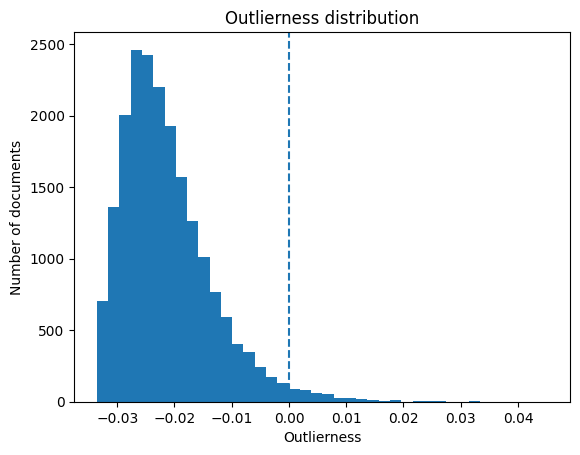

In [ ]:
#we define the expected proportion of outliers in the dataset (I define it again even tought I already did in a cell above, because when I run it, it doesn't recognize it)
contamination = 0.02
#in Isolation Forest when the scores are lower, that means more anomalous
#we invert the sign to obtain an outlierness score, so higher would be more anomalous
outlierness = -scores

#we compute the cut off threshold using the contamination parameter
#so the documents above this value will be considered outliers
threshold = np.quantile(outlierness, 1 - contamination)

#we plot the distribution of outlierness scores
plt.hist(outlierness, bins=40)
#we draw a vertical line indicating the cut off threshold
plt.axvline(threshold, linestyle="--")
plt.xlabel("Outlierness")
plt.ylabel("Number of documents")
plt.title("Outlierness distribution")
plt.show()

## Conclusion: Using Isolation Forest we detected a small number of outliers in the dataset. Most documents have similar outlierness scores, while only a few are clearly different (as we can see above).

# Local Outlier Factor

### After completing the analysis with Isolation Forest, we also apply  LOF to check whether we obtain different results.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

#we apply LOF using the same TF-IDF representation
#n_neighbors controls the local density estimation
#we chose the value of n_neighbors to be 20  because it is a commonly used value that provides a good balance between local sensitivity and robustness
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)

#LOF fits and predicts directly on our dataset
lof_labels = lof.fit_predict(X)

#LOF gives us an outlier score, so the more negative values indicate stronger anomalies
lof_scores = lof.negative_outlier_factor_

#we count the number detected outliers
lof_n_outliers = int((lof_labels == -1).sum())
print("Detected outliers:", lof_n_outliers)

Detected outliers: 600


## Plot of LOF scores

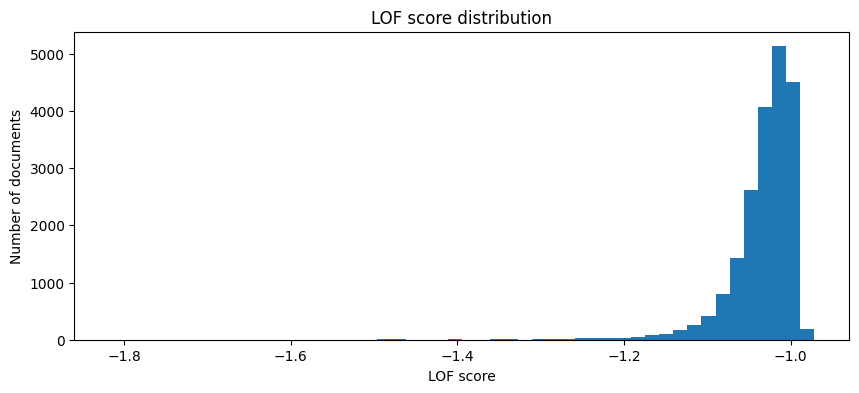

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#LOF scores, more negative means more anomalous
plt.figure(figsize=(10, 4))
plt.hist(lof_scores, bins=50)
plt.title("LOF score distribution")
plt.xlabel("LOF score")
plt.ylabel("Number of documents")
plt.show()

## Examples of outliers detected by LOF

In [ ]:
import numpy as np

#we get the indices of all documents labeled as outliers
lof_outlier_idx = np.where(lof_labels == -1)[0]

#we sort the outliers score and select the most extreme ones
#so the more negative LOF scores indicate stronger anomalies
lof_top_outliers = lof_outlier_idx[np.argsort(lof_scores[lof_outlier_idx])][:5]

#we print a short preview of the most anomalous cleaned documents
for idx in lof_top_outliers:
    print("\n================ OUTLIER DOCUMENT (LOF) ================")
    print("Index:", idx)
    print("LOF score:", lof_scores[idx])
    print("\n--- CLEANED TEXT PREVIEW ---")
    print(docs_clean[idx][:800])


================ OUTLIER DOCUMENT (LOF) ================
Index: 1043
LOF score: -1.8171441370538588

--- CLEANED TEXT PREVIEW ---
xref cantaloupe srv cmu edu talk politics misc soc culture canada soc culture british alt conspiracy newsgroups talk politics misc soc culture canada soc culture british alt conspiracy path cantaloupe srv cmu edu das news harvard edu noc near net howland reston an net zaphod mp ohio state edu utexas edu utnut torn watserv uwaterloo mach brow craig brown subject stop sexularhumanistoppression former beloved damn ferigner take reference message organization wilfrid laurier university date wed apr gmt line article greg otts write article juergen ernst guenther writes never understand canadian mexican brazilian etc accuse people imperialism though think american european think american bunch blasphemeous trash god extinguish sooner later would surprise continent produce fascism communism two w

================ OUTLIER DOCUMENT (LOF) ================
Index: 234

### Conclusion: In this notebook, I applied two outlier detection methods, Isolation Forest and LOF, using the same TF-IDF representation of the textual data. Both methods identified a small proportion of documents as anomalous, which indicates that most texts in the dataset follow similar patterns. At the beggining I noticed that when using the same contamination value, both methods produced very similar results. This suggests that the detected outliers are clearly different from the majority of documents. To better explore the behavior of LOF and to see if there would be any differences in comparison to Isolation Forest, I slightly increased its contamination value. As expected, this led to a higher number of detected outliers, while the overall distribution of LOF scores remained almost unchanged.